# TF Aplicaciones de Data Science - Detección de Idiomas
En este notebook realizaremos la descarga, limpieza y análisis exploratorio de un dataset de textos en múltiples idiomas.

### Integrantes:

- Alexander Miranda Vivanco
- Leonardo Mathias Juscamayta Trujillo
- Diego Fabrizio Mucha Alvarez

## 1. Carga de Datos

Descargar data de cada lenguaje para Spacy

In [1]:
!python -m spacy download en_core_web_sm   # inglés
!python -m spacy download es_core_news_sm  # español
!python -m spacy download fr_core_news_sm  # francés
!python -m spacy download de_core_news_sm  # alemán
!python -m spacy download pt_core_news_sm  # portugués
!python -m spacy download it_core_news_sm  # italiano
!python -m spacy download nl_core_news_sm  # holandés
!python -m spacy download el_core_news_sm  # griego
!python -m spacy download ru_core_news_sm  # ruso
!python -m spacy download da_core_news_sm  # danish
!python -m spacy download sv_core_news_sm  # swedish

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 125.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 97.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 94.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('

Importar las librerias necesarias

In [34]:
import pandas as pd
import re
import unicodedata
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords

import zipfile
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, accuracy_score

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Descarga del dataset de Kaggle

In [3]:
!curl -L -o dataset.zip https://www.kaggle.com/api/v1/datasets/download/basilb2s/language-detection

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  542k  100  542k    0     0  1940k      0 --:--:-- --:--:-- --:--:-- 1940k


Descompresión del dataset

In [4]:
# Descomprimir el archivo descargado en el directorio actual
if os.path.exists('dataset.zip'):
    with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
        zip_ref.extractall('./')

Cargar el dataset en un pandas DataFrame

In [5]:
df = pd.read_csv("Language Detection.csv")

## 2. Exploración Inicial
Revisamos la estructura del dataframe, tipos de datos y presencia de valores nulos.

In [6]:
df.head()

,Text,Language
0,"Nature, in the broadest sense, is the natural...",English
1,"""Nature"" can refer to the phenomena of the phy...",English
2,"The study of nature is a large, if not the onl...",English
3,"Although humans are part of nature, human acti...",English
4,[1] The word nature is borrowed from the Old F...,English


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10337 entries, 0 to 10336
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Text      10337 non-null  object
 1   Language  10337 non-null  object
dtypes: object(2)
memory usage: 161.6+ KB


In [8]:
print("Valores nulos por coulmna:")
print(df.isnull().sum())

Valores nulos por coulmna:
Text        0
Language    0
dtype: int64


In [9]:
df.shape

(10337, 2)

## 3. Preprocesamiento (Normalización)
Definimos una función de limpieza para normalizar el texto (minúsculas, eliminar puntuación, números, tokenizar y lematizar) y filtramos los idiomas que no cuentan con soporte de stopwords en NLTK.

In [10]:
def limpiar_texto(texto, idioma='english', quitar_acentos=False):
    # lowercase
    texto = texto.lower()

    # Normalizar unicode
    texto = unicodedata.normalize('NFC', texto)

    # Quitar números
    texto = re.sub(r'\d+', '', texto)

    # Quitar puntuación
    texto = re.sub(r'[^\w\s]', '', texto)

    # Quitar espacios extra
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

# Aplicar al dataframe
df['clean_text'] = df['Text'].apply(limpiar_texto)

In [11]:
df.head()

,Text,Language,clean_text
0,"Nature, in the broadest sense, is the natural...",English,nature in the broadest sense is the natural ph...
1,"""Nature"" can refer to the phenomena of the phy...",English,nature can refer to the phenomena of the physi...
2,"The study of nature is a large, if not the onl...",English,the study of nature is a large if not the only...
3,"Although humans are part of nature, human acti...",English,although humans are part of nature human activ...
4,[1] The word nature is borrowed from the Old F...,English,the word nature is borrowed from the old frenc...


In [12]:
df['Language'].unique()

array(['English', 'Malayalam', 'Hindi', 'Tamil', 'Portugeese', 'French',
       'Dutch', 'Spanish', 'Greek', 'Russian', 'Danish', 'Italian',
       'Turkish', 'Sweedish', 'Arabic', 'German', 'Kannada'], dtype=object)

In [13]:
# Dropearemos las filas con los idiomas que nltk ni spacy no soporta
idiomas_a_eliminar = ['Malayalam', 'Hindi', 'Tamil', 'Kannada', 'Arabic', 'Turkish']
df = df[~df['Language'].isin(idiomas_a_eliminar)].copy()

In [14]:
from nltk.corpus import stopwords

LANG_MAP = {
    'English':    'english',
    'French':     'french',
    'Spanish':    'spanish',
    'Portugeese': 'portuguese',
    'Italian':    'italian',
    'Russian':    'russian',
    'Sweedish':   'swedish',
    'Dutch':      'dutch',
    'German':     'german',
    'Danish':     'danish',
    'Greek':      'greek'
}

def tokenizar(texto, idioma_nltk='english'):
    tokens = texto.split()
    sw = set(stopwords.words(idioma_nltk))
    tokens = [t for t in tokens if t not in sw]
    return tokens

# Aplicar segun idioma de cada fila
df['tokens'] = df.apply(
    lambda row: tokenizar(
        row['clean_text'],
        LANG_MAP.get(row['Language'], 'english')
    ), axis=1
)

In [15]:
df['tokens'].head()

,tokens
0,"[nature, broadest, sense, natural, physical, m..."
1,"[nature, refer, phenomena, physical, world, al..."
2,"[study, nature, large, part, science]"
3,"[although, humans, part, nature, human, activi..."
4,"[word, nature, borrowed, old, french, nature, ..."


In [16]:
import spacy

MODELOS = {
    'English':    (spacy.load('en_core_web_sm'), 'spacy'),
    'Portugeese': (spacy.load('pt_core_news_sm'), 'spacy'),
    'French':     (spacy.load('fr_core_news_sm'), 'spacy'),
    'Dutch':      (spacy.load('nl_core_news_sm'), 'spacy'),
    'Spanish':    (spacy.load('es_core_news_sm'), 'spacy'),
    'Greek':      (spacy.load('el_core_news_sm'), 'spacy'),
    'Russian':    (spacy.load('ru_core_news_sm'), 'spacy'),
    'Italian':    (spacy.load('it_core_news_sm'), 'spacy'),
    'German':     (spacy.load('de_core_news_sm'), 'spacy'),
    'Sweedish':   (spacy.load("sv_core_news_sm"), 'spacy'),
    'Danish':     (spacy.load("da_core_news_sm"), 'spacy'),
}

def lematizar(texto, idioma):
    model, lib_type = MODELOS[idioma]

    return [
        token.lemma_.lower()
        for token in model(texto)
        if not token.is_stop and not token.is_punct and token.is_alpha
    ]

df['lemas_norm'] = df.apply(
    lambda row: lematizar(' '.join(row['tokens']), row['Language']),
    axis=1
)

In [17]:
df['lemas_norm'].head()

,lemas_norm
0,"[nature, broad, sense, natural, physical, mate..."
1,"[nature, refer, phenomena, physical, world, li..."
2,"[study, nature, large, science]"
3,"[human, nature, human, activity, understand, s..."
4,"[word, nature, borrow, old, french, nature, de..."


In [18]:
df.to_csv("data_procesada.csv")

## 4. Análisis de Frecuencia
Calculamos las palabras más comunes tanto de forma global como por cada idioma individual.

Top 20 palabras (global):
  wikipedia            906
  wikipédia            430
  nature               239
  learning             182
  si                   171
  wikimedia            156
  a                    154
  articles             140
  это                  131
  narcisa              125
  είναι                125
  plus                 117
  data                 115
  oh                   114
  web                  108
  machine              106
  kan                  106
  comme                103
  википедии            100
  dire                 94


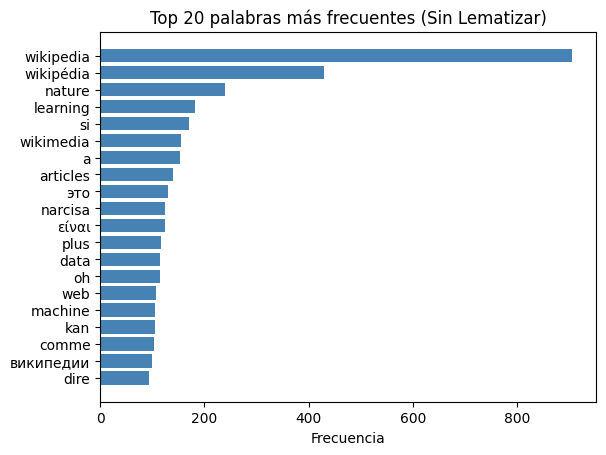

In [19]:
from collections import Counter

todos_tokens = [t for tokens in df['tokens'] for t in tokens]
freq_global = Counter(todos_tokens)
top_global = freq_global.most_common(20)

palabras, conteos = zip(*top_global)

print("Top 20 palabras (global):")
for palabra, count in top_global:
    print(f"  {palabra:20s} {count}")

plt.barh(list(palabras)[::-1], list(conteos)[::-1], color='steelblue')
plt.title('Top 20 palabras más frecuentes (Sin Lematizar)')
plt.xlabel('Frecuencia')
plt.show()

Top 20 palabras (global):
  wikipedia            921
  wikipédia            246
  nature               210
  article              208
  wikipéder            186
  википедия            170
  wikimedia            137
  editor               123
  artikel              118
  learning             116
  machine              115
  oh                   113
  ord                  111
  artigo               110
  artículo             110
  web                  108
  potere               105
  learn                97
  narcisa              97
  год                  95


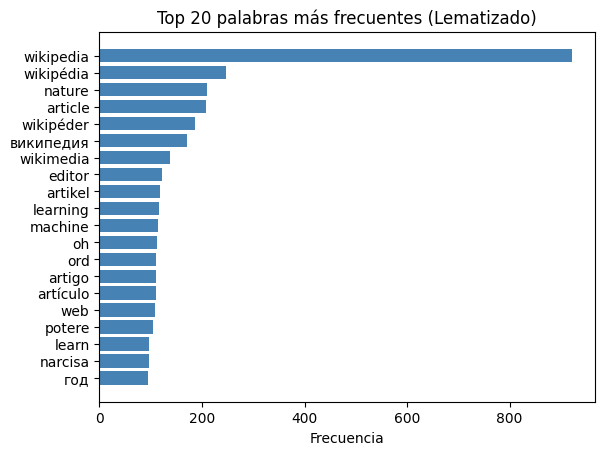

In [20]:
from collections import Counter

todos_tokens_lem = [t for tokens in df['lemas_norm'] for t in tokens]
freq_global_lem = Counter(todos_tokens_lem)
top_global_lem = freq_global_lem.most_common(20)

palabras, conteos = zip(*top_global_lem)

print("Top 20 palabras (global):")
for palabra, count in top_global_lem:
    print(f"  {palabra:20s} {count}")

plt.barh(list(palabras)[::-1], list(conteos)[::-1], color='steelblue')
plt.title('Top 20 palabras más frecuentes (Lematizado)')
plt.xlabel('Frecuencia')
plt.show()

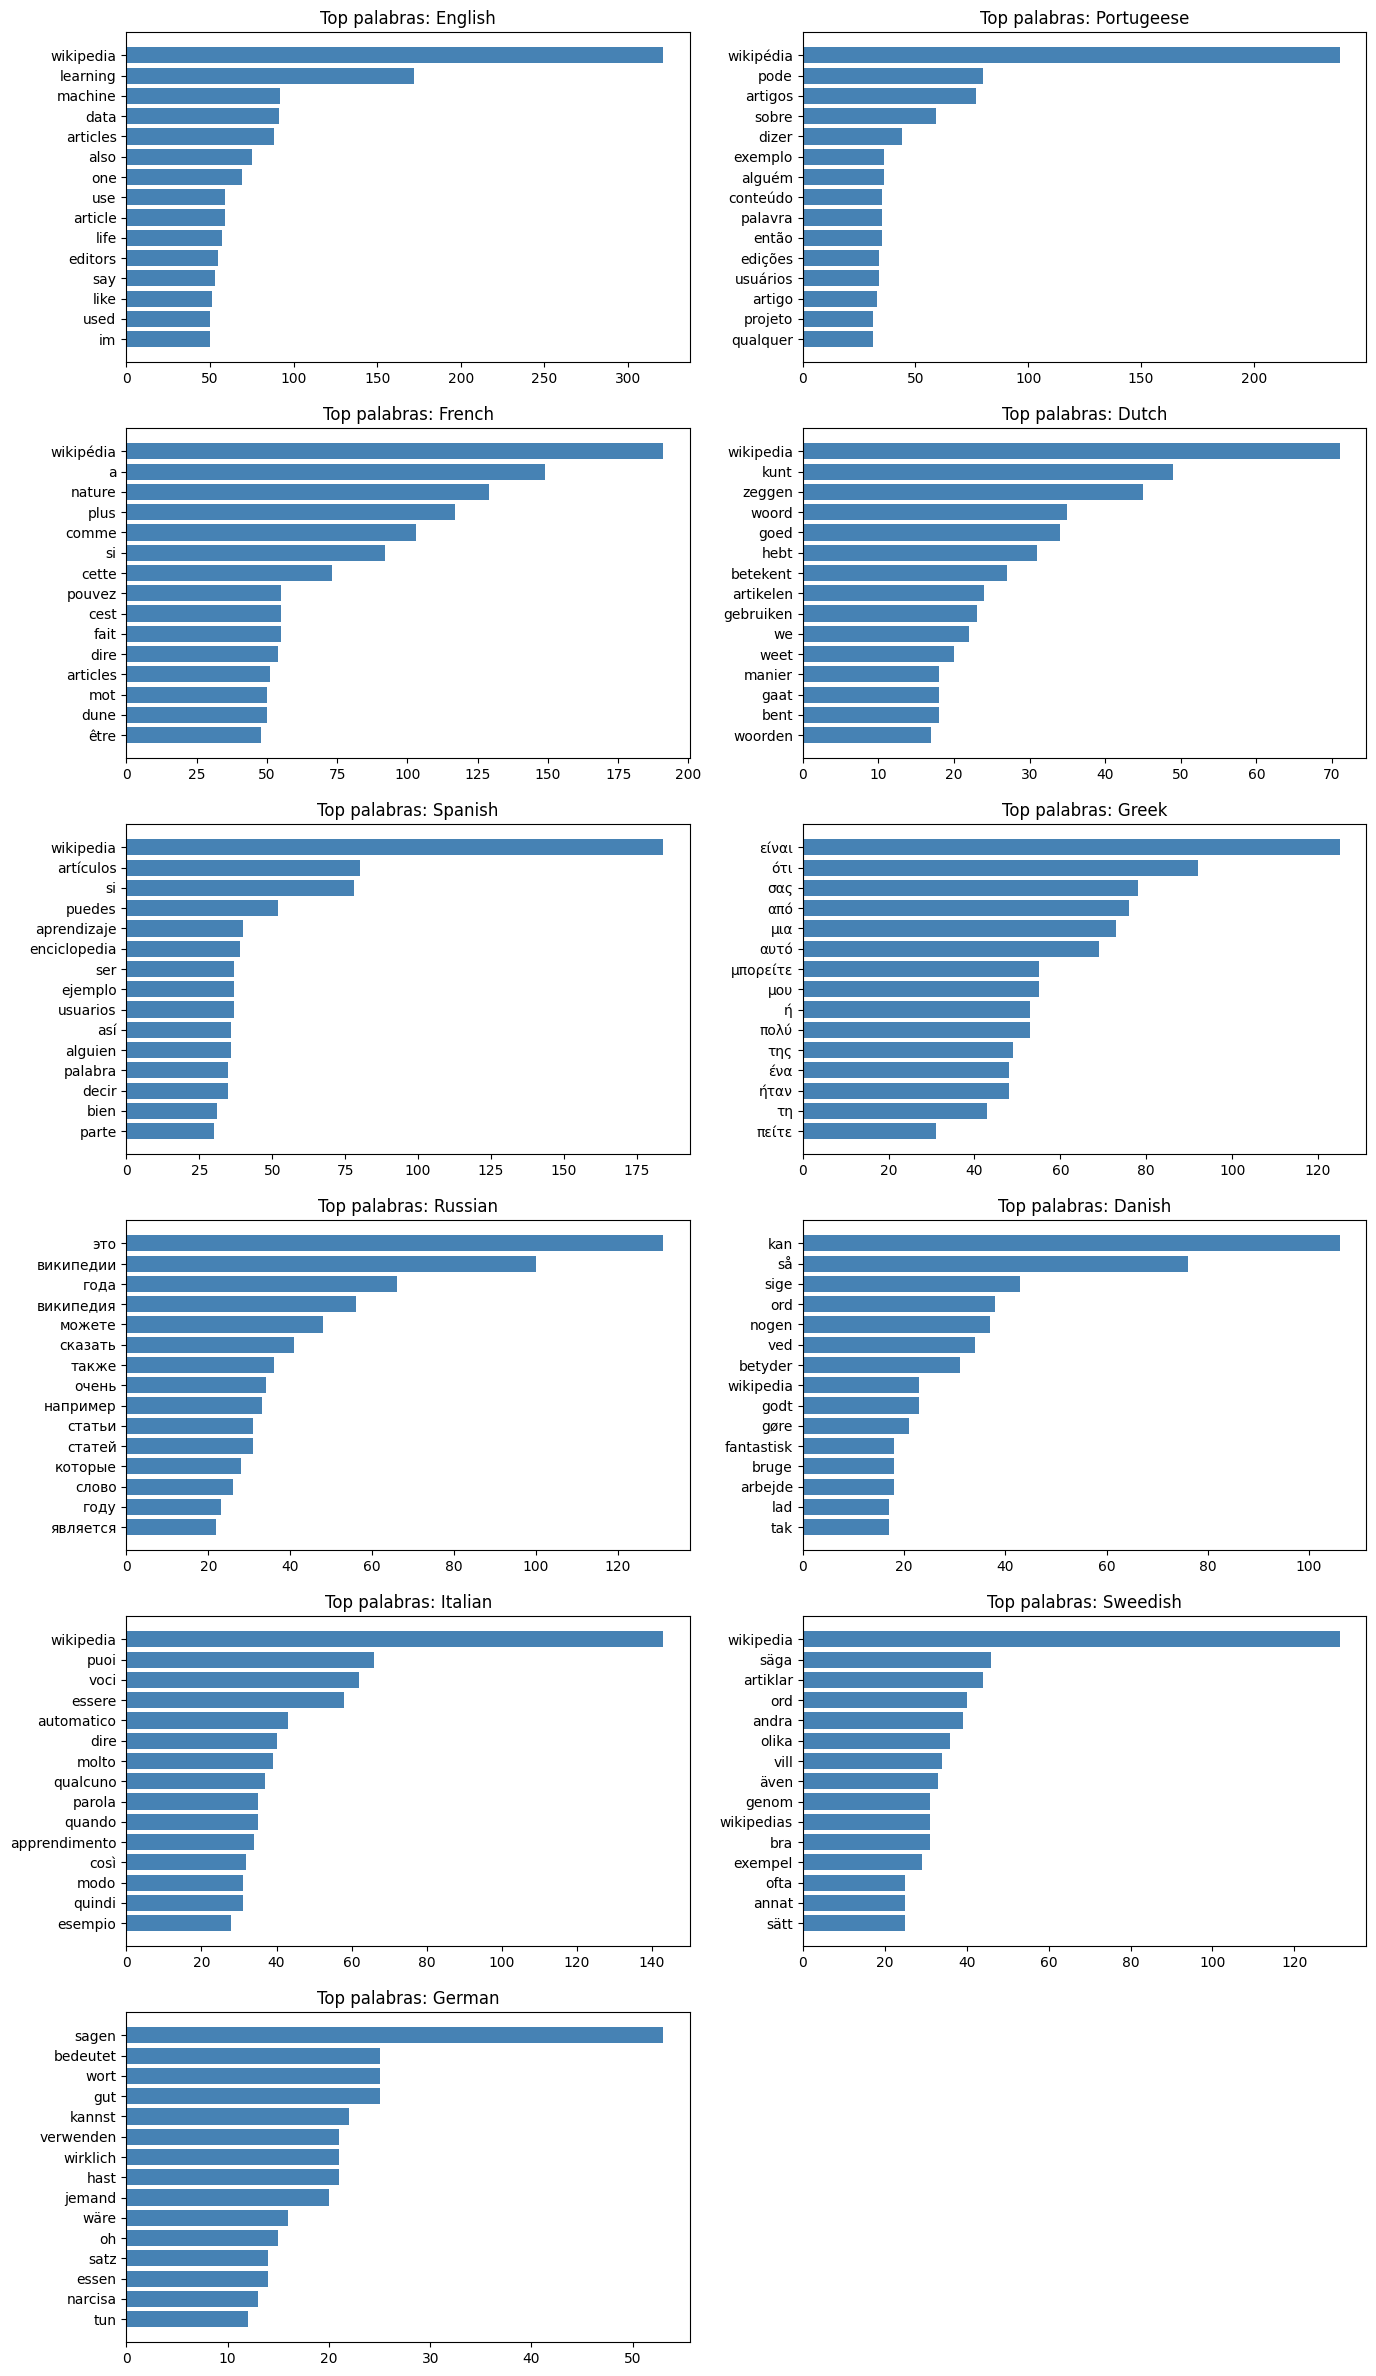

In [21]:
# Función de frecuencia por idioma (Sin Lematizar)
def frecuencia_por_idioma(df, idioma, top_n=15):
    subset = df[df['Language'] == idioma]
    tokens = [t for tokens in subset['tokens'] for t in tokens]
    return Counter(tokens).most_common(top_n)

freq_por_idioma = []
for lang in df['Language'].unique():
    freq_por_idioma.append((lang, frecuencia_por_idioma(df, lang)))

n_cols = 2
n_rows = (len(freq_por_idioma) + 1) // n_cols
fig, ax = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
ax = ax.flatten()

for index, (lang, freq_dist) in enumerate(freq_por_idioma):
    if not freq_dist: continue
    palabras, conteos = zip(*freq_dist)

    ax[index].barh(list(palabras)[::-1], list(conteos)[::-1], color='steelblue')
    ax[index].set_title(f'Top palabras: {lang}')

# Limpiar subplots vacíos
for i in range(len(freq_por_idioma), len(ax)):
    fig.delaxes(ax[i])

plt.show()

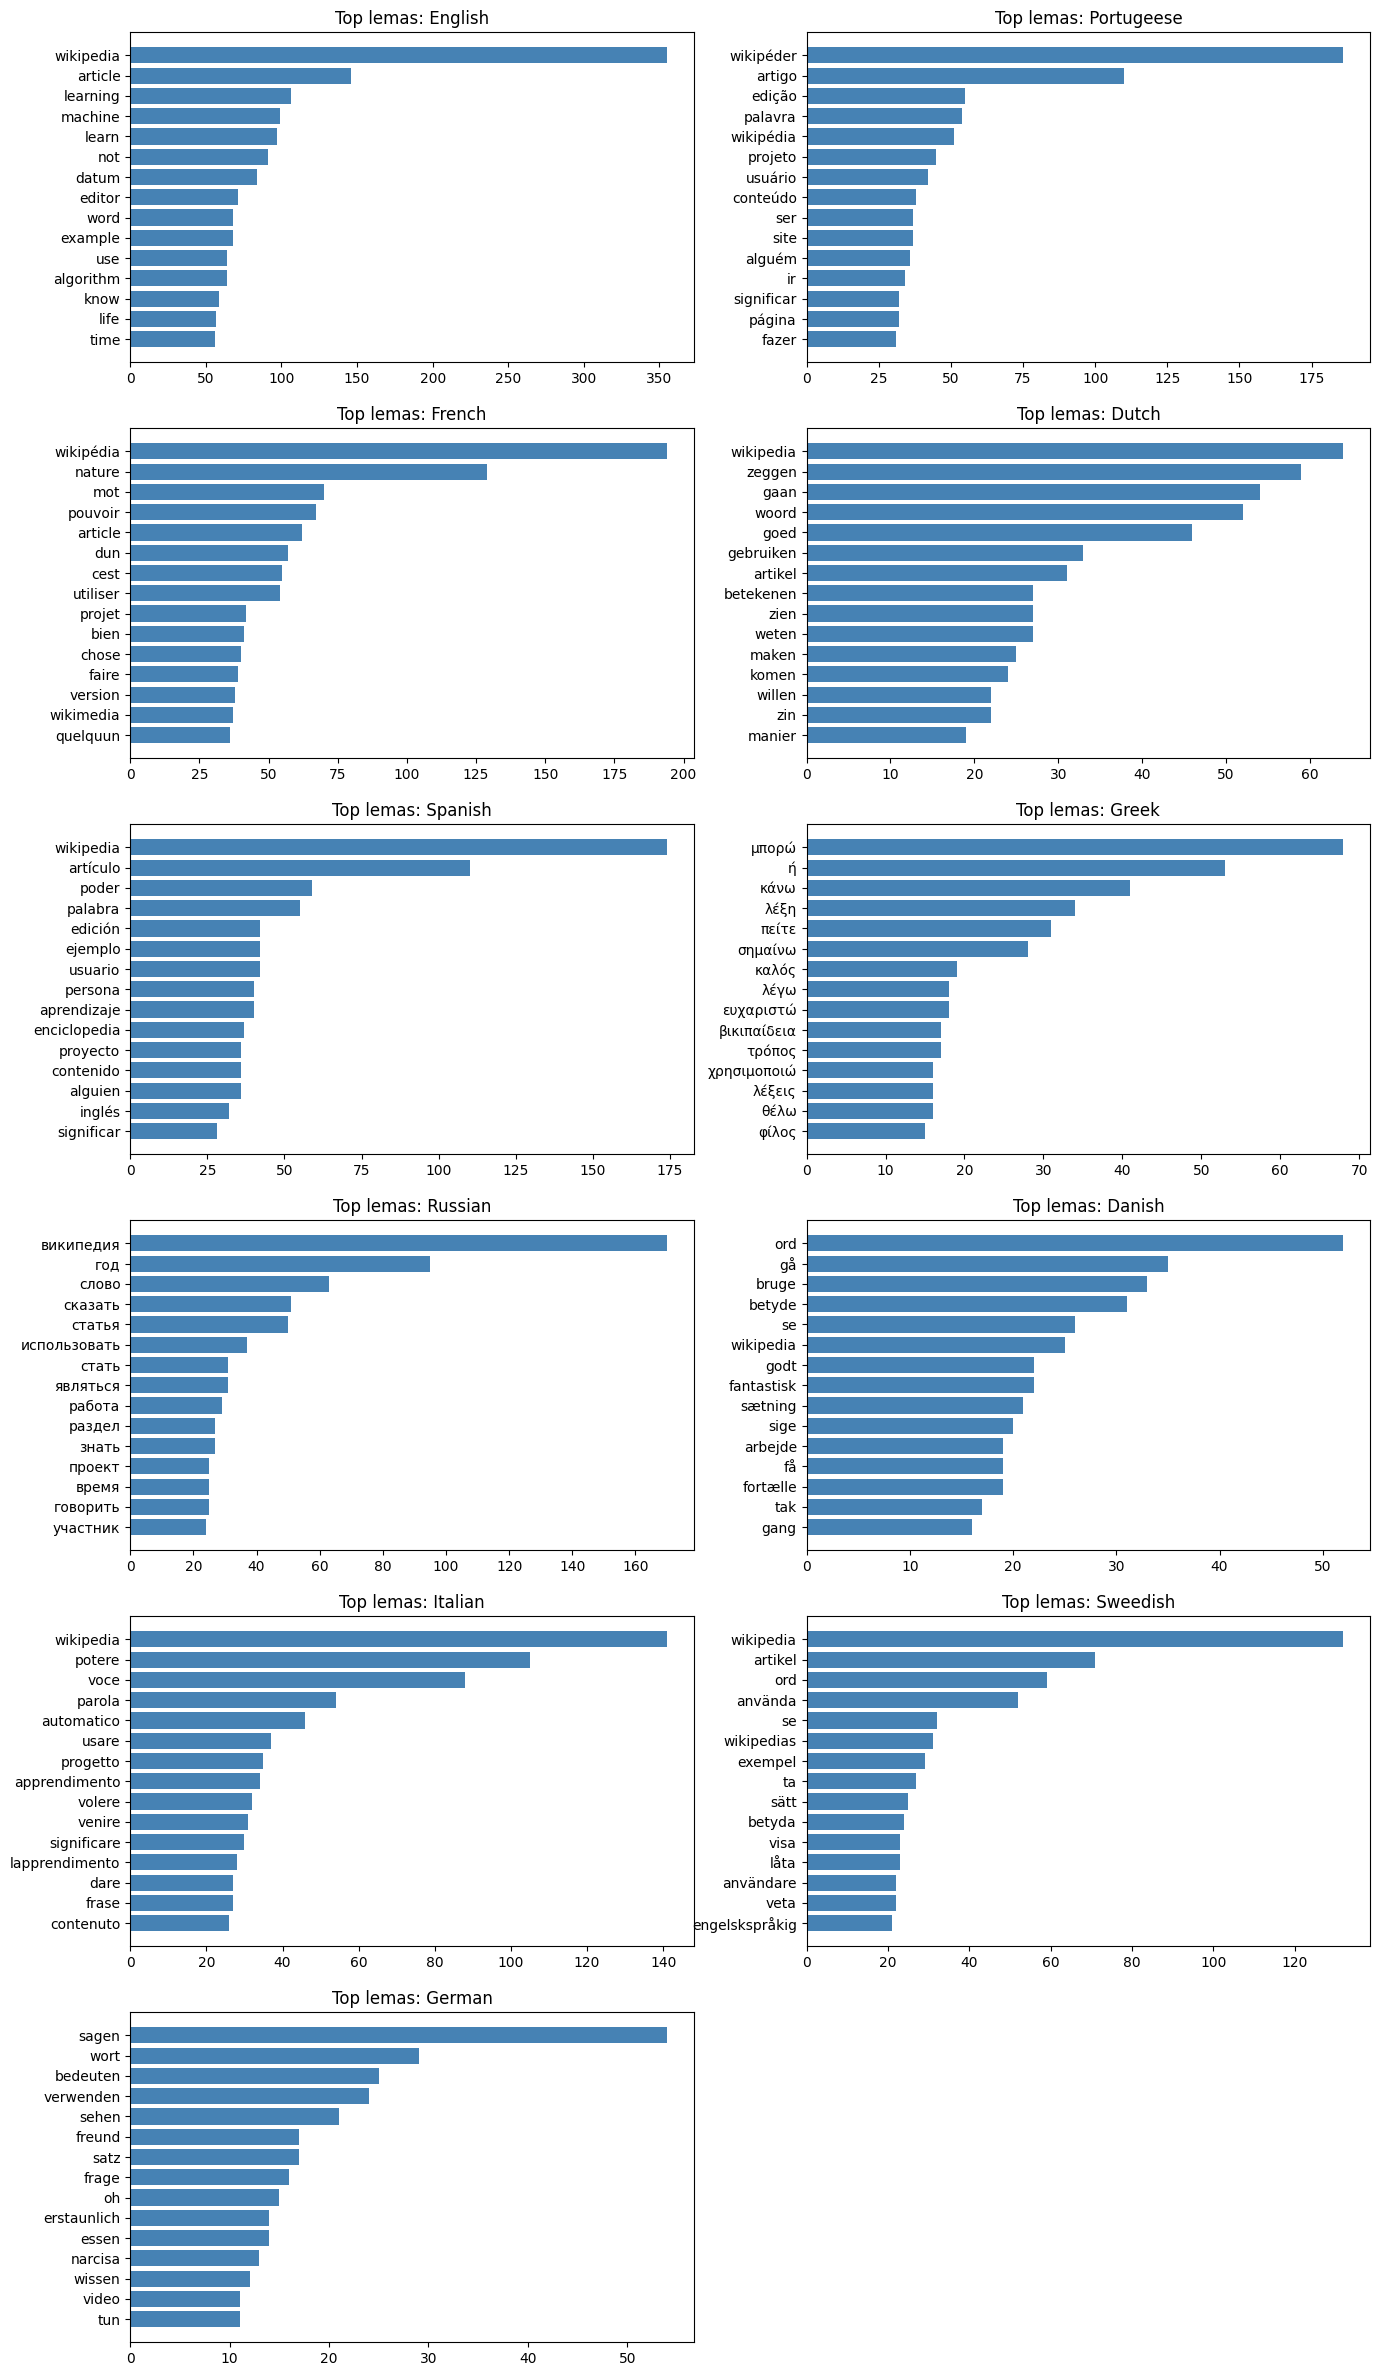

In [22]:
# Función de frecuencia por idioma (Lematizado)
def frecuencia_por_idioma_lem(df, idioma, top_n=15):
    subset = df[df['Language'] == idioma]
    tokens = [t for tokens in subset['lemas_norm'] for t in tokens]
    return Counter(tokens).most_common(top_n)

freq_por_idioma_lem = []
for lang in df['Language'].unique():
    freq_por_idioma_lem.append((lang, frecuencia_por_idioma_lem(df, lang)))

n_cols = 2
n_rows = (len(freq_por_idioma_lem) + 1) // n_cols
fig, ax = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
ax = ax.flatten()

for index, (lang, freq_dist_lem) in enumerate(freq_por_idioma_lem):
    if not freq_dist_lem: continue
    palabras_lem, conteos_lem = zip(*freq_dist_lem)

    ax[index].barh(list(palabras_lem)[::-1], list(conteos_lem)[::-1], color='steelblue')
    ax[index].set_title(f'Top lemas: {lang}')

# Limpiar subplots vacíos
for i in range(len(freq_por_idioma_lem), len(ax)):
    fig.delaxes(ax[i])

plt.show()

## 5. Visualización de Resultados
Generamos gráficos para comparar la riqueza léxica (palabras únicas), la distribución de clases y una nube de palabras general.

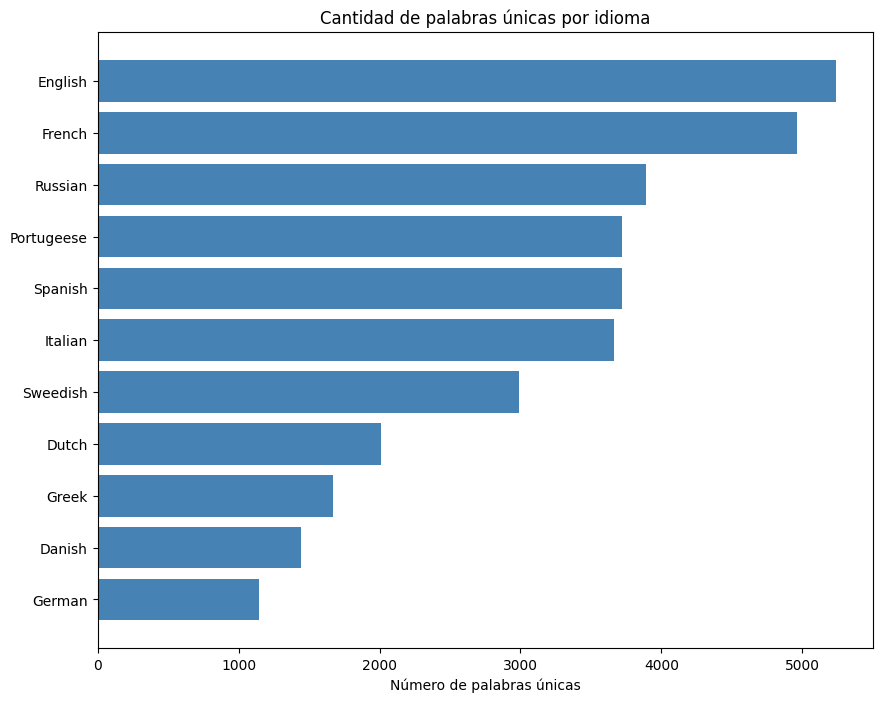

In [23]:
def unique_por_idioma(df, idioma):
    subset = df[df['Language'] == idioma]
    tokens = [t for tokens in subset['tokens'] for t in tokens]
    return len(set(tokens))

uq_por_idioma = []
for lang in df['Language'].unique():
    conteo = unique_por_idioma(df, lang)
    uq_por_idioma.append((lang, conteo))

uq_por_idioma.sort(key=lambda x: x[1])

palabras_uq, conteos_uq = zip(*uq_por_idioma)

plt.figure(figsize=(10, 8))
plt.barh(palabras_uq, conteos_uq, color='steelblue')
plt.title('Cantidad de palabras únicas por idioma')
plt.xlabel('Número de palabras únicas')
plt.show()

## 6. Riqueza Léxica por Idioma
Calculamos la proporción de palabras únicas respecto al total de palabras para medir la diversidad del vocabulario en cada idioma.

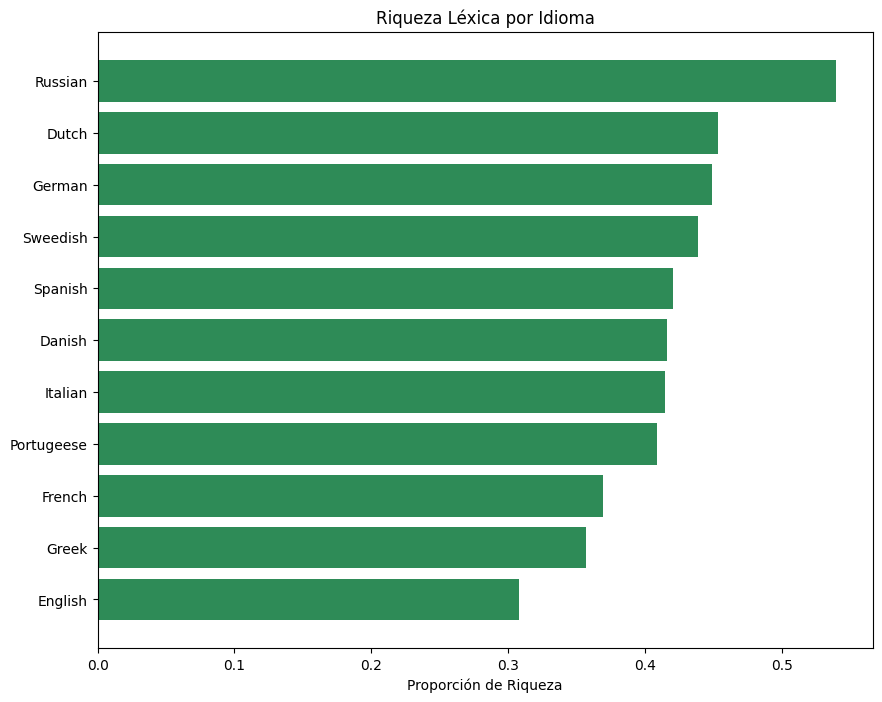

In [24]:
def calcular_riqueza_lexica(df, idioma):
    subset = df[df['Language'] == idioma]
    tokens = [t for tokens in subset['tokens'] for t in tokens]
    if not tokens: return 0
    return len(set(tokens)) / len(tokens)

riqueza_data = []
for lang in df['Language'].unique():
    score = calcular_riqueza_lexica(df, lang)
    riqueza_data.append((lang, score))

# Ordenar por riqueza léxica
riqueza_data.sort(key=lambda x: x[1])
idiomas_list, richness_scores = zip(*riqueza_data)

plt.figure(figsize=(10, 8))
plt.barh(idiomas_list, richness_scores, color='seagreen')
plt.title('Riqueza Léxica por Idioma')
plt.xlabel('Proporción de Riqueza')
plt.show()

## 7. Distribución de Clases y Nube de Palabras
Visualizamos qué tan balanceado está el dataset y las palabras más prominentes de forma visual.

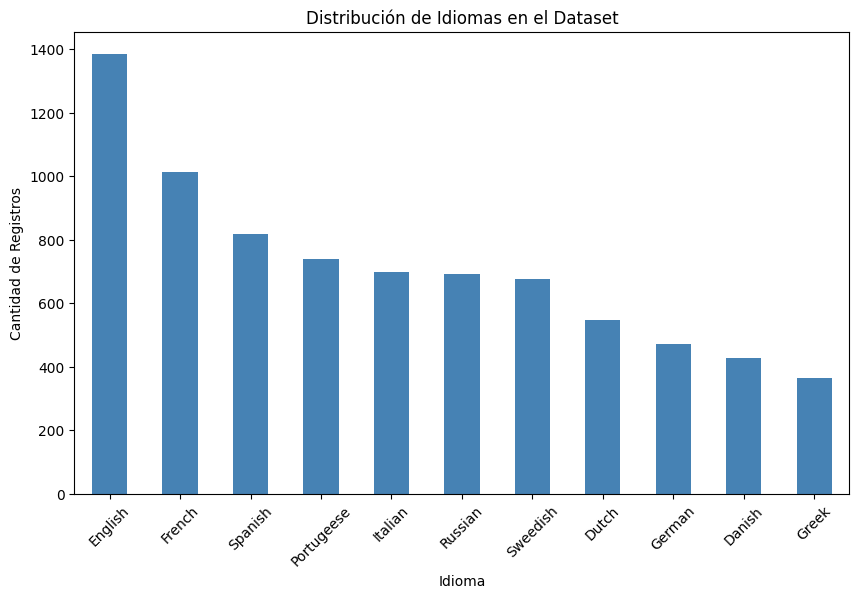

In [25]:
counts = df['Language'].value_counts()

plt.figure(figsize=(10, 6))
counts.plot(kind='bar', color='steelblue')
plt.title('Distribución de Idiomas en el Dataset')
plt.xlabel('Idioma')
plt.ylabel('Cantidad de Registros')
plt.xticks(rotation=45)
plt.show()

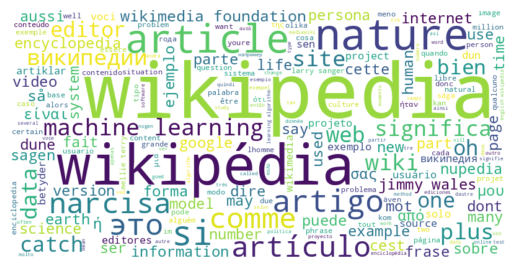

In [26]:
from wordcloud import WordCloud

texto_concat = ' '.join(todos_tokens)
wc = WordCloud(width=800, height=400, background_color='white')
wc.generate(texto_concat)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [27]:
df.head()

,Text,Language,clean_text,tokens,lemas_norm
0,"Nature, in the broadest sense, is the natural...",English,nature in the broadest sense is the natural ph...,"[nature, broadest, sense, natural, physical, m...","[nature, broad, sense, natural, physical, mate..."
1,"""Nature"" can refer to the phenomena of the phy...",English,nature can refer to the phenomena of the physi...,"[nature, refer, phenomena, physical, world, al...","[nature, refer, phenomena, physical, world, li..."
2,"The study of nature is a large, if not the onl...",English,the study of nature is a large if not the only...,"[study, nature, large, part, science]","[study, nature, large, science]"
3,"Although humans are part of nature, human acti...",English,although humans are part of nature human activ...,"[although, humans, part, nature, human, activi...","[human, nature, human, activity, understand, s..."
4,[1] The word nature is borrowed from the Old F...,English,the word nature is borrowed from the old frenc...,"[word, nature, borrowed, old, french, nature, ...","[word, nature, borrow, old, french, nature, de..."


## 8. Modelado
Ahora que ya existe un dataframe con la data procesada. Se va a aplicar 3 modelos distintos para predecir el idioma de la oración, que son:

1. **N-gramas + Naive Bayes**
2. **N-gramas + Regresión Logística**
3. **N-Gramas + TF-IDF + Regresión Logística**

Antes de empezar con el modelado, se hace una división de la data en train y test

In [28]:
# --- Division train/test ---
df['tokens_joined'] = df['tokens'].apply(lambda toks: ' '.join(toks))

X_train, X_test, y_train, y_test = train_test_split(
    df['tokens_joined'], df['Language'], test_size=0.2, random_state=42, stratify=df['Language']
)

### 8.1. N-gramas + Naive Bayes

**Creamos el modelo a traves de un pipeline y lo entrenamos**

In [29]:
pipe_nb = Pipeline([
    ('ngrams', CountVectorizer(analyzer='char_wb', ngram_range=(1, 3), min_df=2)),
    ('clf', MultinomialNB())
])

pipe_nb.fit(X_train, y_train)

Pipeline(steps=[('ngrams',
                 CountVectorizer(analyzer='char_wb', min_df=2,
                                 ngram_range=(1, 3))),
                ('clf', MultinomialNB())])

**Testeamos el modelo**

In [30]:
pred_nb = pipe_nb.predict(X_test)

print("=== N-gramas + Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, pred_nb))
print(classification_report(y_test, pred_nb))

=== N-gramas + Naive Bayes ===
Accuracy: 0.9546904913848118
              precision    recall  f1-score   support

      Danish       0.93      0.86      0.89        86
       Dutch       0.93      0.93      0.93       109
     English       0.94      0.98      0.96       277
      French       0.97      0.97      0.97       203
      German       1.00      0.89      0.94        94
       Greek       1.00      1.00      1.00        73
     Italian       0.95      0.96      0.95       140
  Portugeese       0.98      0.96      0.97       148
     Russian       1.00      0.99      1.00       138
     Spanish       0.96      0.93      0.94       164
    Sweedish       0.88      0.96      0.92       135

    accuracy                           0.95      1567
   macro avg       0.96      0.95      0.95      1567
weighted avg       0.96      0.95      0.95      1567



In [35]:
prob_nb = pipe_nb.predict_proba(X_test)
classes = pipe_nb.classes_
y_test_bin = label_binarize(y_test, classes=classes)

macro_auc = roc_auc_score(y_test_bin, prob_nb, multi_class="ovr", average="macro")
weighted_auc = roc_auc_score(y_test_bin, prob_nb, multi_class="ovr", average="weighted")
micro_auc = roc_auc_score(y_test_bin, prob_nb, average="micro")

print("ROC-AUC macro:", macro_auc)
print("ROC-AUC weighted:", weighted_auc)
print("ROC-AUC micro:", micro_auc)

ROC-AUC macro: 0.998881797239698
ROC-AUC weighted: 0.9989426062047198
ROC-AUC micro: 0.9990698390422437


**Gráficos para la evaluación**

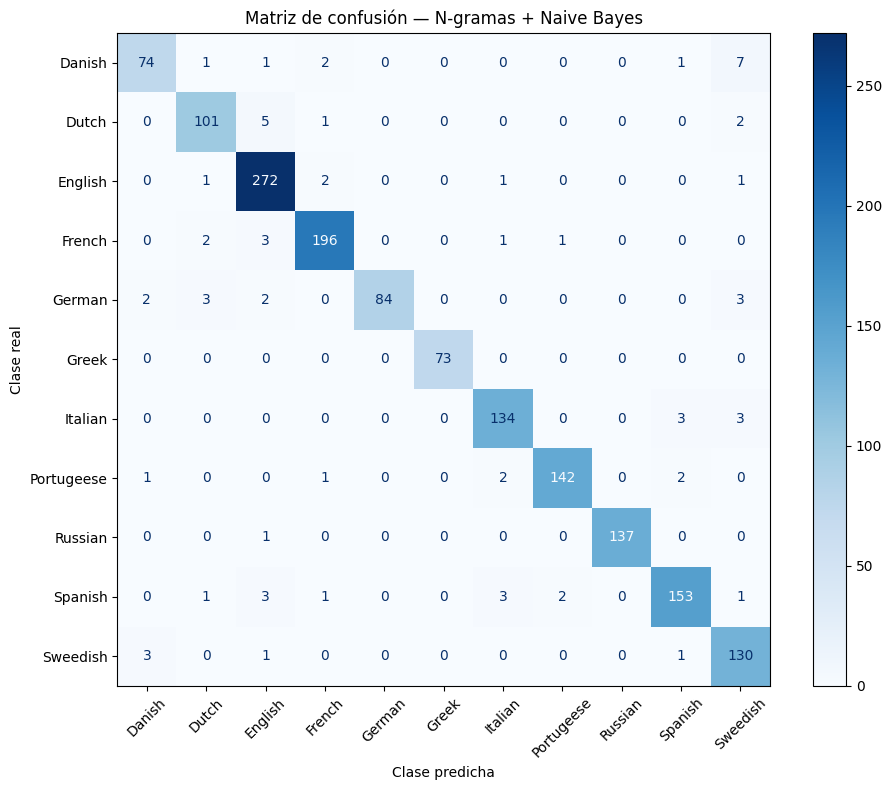

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    pred_nb,
    labels=classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(10, 8))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45
)

plt.title("Matriz de confusión — N-gramas + Naive Bayes")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()

### 8.2. N-gramas + Regresión Logística

**Creamos el modelo a traves de un pipeline y lo entrenamos**

In [37]:
pipe_lr_count = Pipeline([
    ('ngrams', CountVectorizer(analyzer='char_wb', ngram_range=(1, 3), min_df=2)),
    ('clf', LogisticRegression(max_iter=1000, n_jobs=-1))
])

pipe_lr_count.fit(X_train, y_train)


Pipeline(steps=[('ngrams',
                 CountVectorizer(analyzer='char_wb', min_df=2,
                                 ngram_range=(1, 3))),
                ('clf', LogisticRegression(max_iter=1000, n_jobs=-1))])

**Testeamos el modelo**

In [38]:
pred_lr_count = pipe_lr_count.predict(X_test)

print("=== N-gramas + Regresión Logística ===")
print("Accuracy:", accuracy_score(y_test, pred_lr_count))
print(classification_report(y_test, pred_lr_count))

=== N-gramas + Regresión Logística ===
Accuracy: 0.9438417358008935
              precision    recall  f1-score   support

      Danish       0.94      0.91      0.92        86
       Dutch       0.96      0.96      0.96       109
     English       0.95      0.96      0.96       277
      French       0.98      0.94      0.96       203
      German       0.97      0.96      0.96        94
       Greek       1.00      1.00      1.00        73
     Italian       0.94      0.95      0.95       140
  Portugeese       0.89      0.91      0.90       148
     Russian       0.98      1.00      0.99       138
     Spanish       0.88      0.85      0.86       164
    Sweedish       0.92      0.97      0.95       135

    accuracy                           0.94      1567
   macro avg       0.95      0.95      0.95      1567
weighted avg       0.94      0.94      0.94      1567



In [39]:
prob_lr_count = pipe_lr_count.predict_proba(X_test)
classes = pipe_lr_count.classes_
y_test_bin = label_binarize(y_test, classes=classes)

macro_auc = roc_auc_score(y_test_bin, prob_lr_count, multi_class="ovr", average="macro")

weighted_auc = roc_auc_score(y_test_bin, prob_lr_count, multi_class="ovr", average="weighted")

micro_auc = roc_auc_score(y_test_bin, prob_lr_count, average="micro")

print("ROC-AUC macro:", macro_auc)
print("ROC-AUC weighted:", weighted_auc)
print("ROC-AUC micro:", micro_auc)

ROC-AUC macro: 0.9982986402267152
ROC-AUC weighted: 0.9982040521497154
ROC-AUC micro: 0.9986221481749664


**Gráficos para la evaluación**

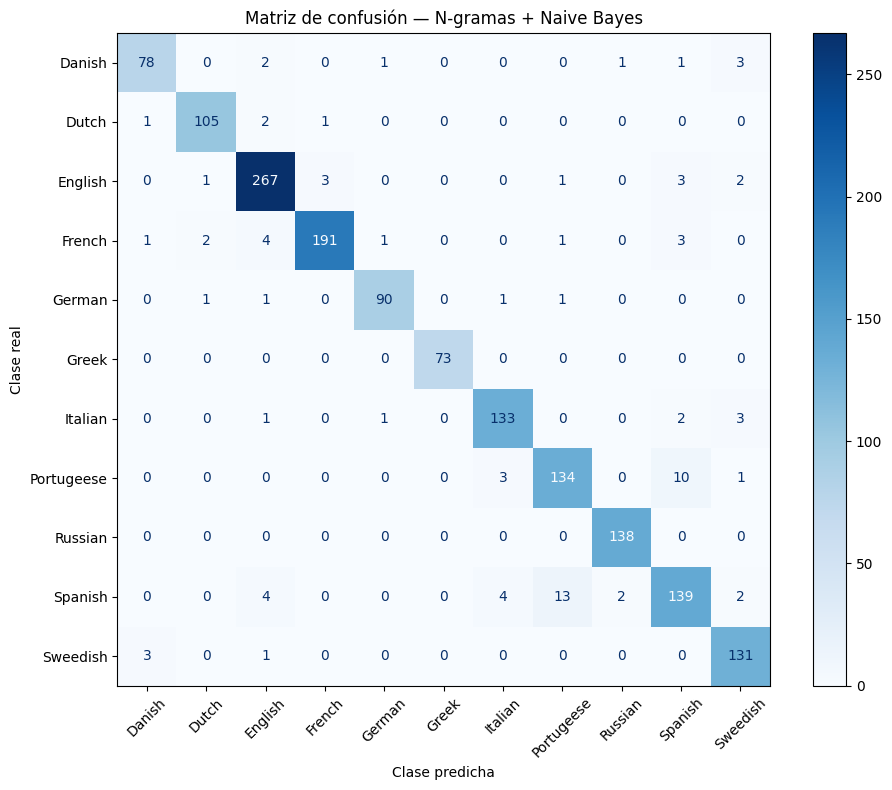

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    pred_lr_count,
    labels=classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(10, 8))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45
)

plt.title("Matriz de confusión — N-gramas + Naive Bayes")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()

### 8.3. N-gramas + TF-IDF + Regresión Logística

**Creamos el modelo a traves de un pipeline y lo entrenamos**

In [41]:
pipe_lr_tfidf = Pipeline([
    ('ngrams', TfidfVectorizer(analyzer='char_wb', ngram_range=(1, 3), min_df=2, sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=1000, n_jobs=-1))
])

pipe_lr_tfidf.fit(X_train, y_train)


Pipeline(steps=[('ngrams',
                 TfidfVectorizer(analyzer='char_wb', min_df=2,
                                 ngram_range=(1, 3), sublinear_tf=True)),
                ('clf', LogisticRegression(max_iter=1000, n_jobs=-1))])

**Testeamos el modelo**

In [42]:
pred_lr_tfidf = pipe_lr_tfidf.predict(X_test)

print("=== N-gramas + TF-IDF + Regresión Logística ===")
print("Accuracy:", accuracy_score(y_test, pred_lr_tfidf))
print(classification_report(y_test, pred_lr_tfidf))

=== N-gramas + TF-IDF + Regresión Logística ===
Accuracy: 0.9604339502233568
              precision    recall  f1-score   support

      Danish       0.95      0.92      0.93        86
       Dutch       0.98      0.93      0.95       109
     English       0.94      0.99      0.96       277
      French       0.98      0.96      0.97       203
      German       0.97      0.97      0.97        94
       Greek       1.00      1.00      1.00        73
     Italian       0.96      0.98      0.97       140
  Portugeese       0.95      0.94      0.95       148
     Russian       0.98      1.00      0.99       138
     Spanish       0.94      0.90      0.92       164
    Sweedish       0.95      0.97      0.96       135

    accuracy                           0.96      1567
   macro avg       0.96      0.96      0.96      1567
weighted avg       0.96      0.96      0.96      1567



In [43]:
prob_lr_tfidf = pipe_lr_tfidf.predict_proba(X_test)
classes = pipe_lr_tfidf.classes_
y_test_bin = label_binarize(y_test, classes=classes)

macro_auc = roc_auc_score(y_test_bin, prob_lr_tfidf, multi_class="ovr", average="macro")

weighted_auc = roc_auc_score(y_test_bin, prob_lr_tfidf, multi_class="ovr", average="weighted")

micro_auc = roc_auc_score(y_test_bin, prob_lr_tfidf, average="micro")

print("ROC-AUC macro:", macro_auc)
print("ROC-AUC weighted:", weighted_auc)
print("ROC-AUC micro:", micro_auc)

ROC-AUC macro: 0.9981399948662553
ROC-AUC weighted: 0.9982414541597912
ROC-AUC micro: 0.9985611012714778


**Gráficos para la evaluación**

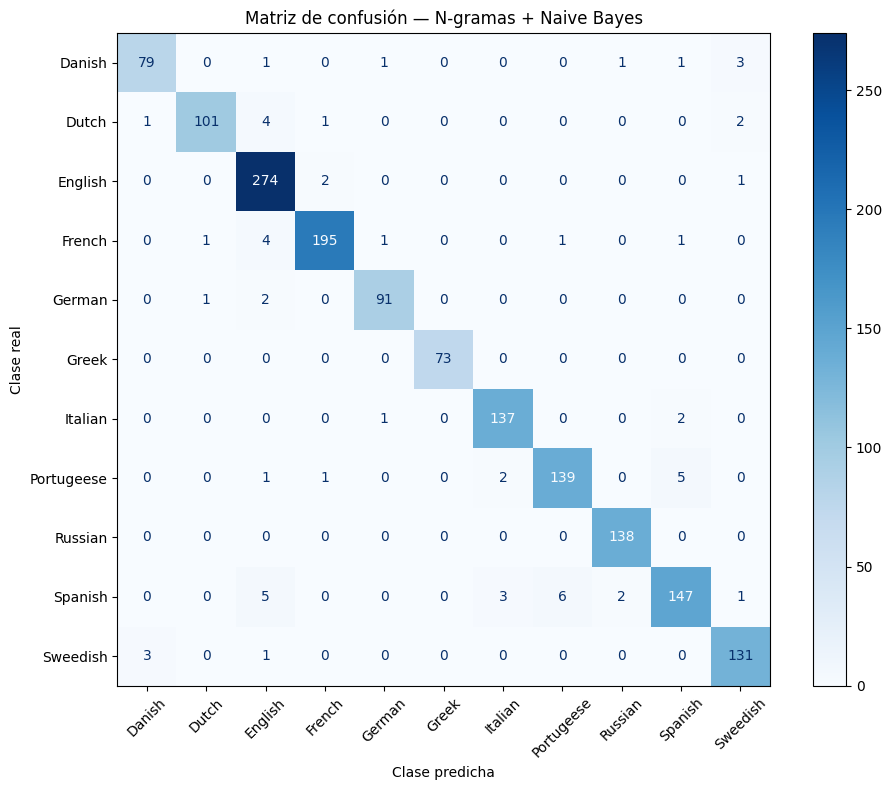

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    pred_lr_tfidf,
    labels=classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(10, 8))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45
)

plt.title("Matriz de confusión — N-gramas + Naive Bayes")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()

## 9. Pipeline de Predicción de Idioma

In [45]:
def predict_language(text):
    # Aplicar limpieza de texto
    clean_text = limpiar_texto(text)

    predicted_lang = pipe_lr_tfidf.predict([clean_text])[0]
    return predicted_lang

### Probar el predictor con un ejemplo:

In [46]:
text_input = input("Escribe una frase en cualquier idioma para predecir: ")
predicted_language = predict_language(text_input)
print(f"El idioma predicho es: {predicted_language}")

Escribe una frase en cualquier idioma para predecir: a
El idioma predicho es: Portugeese
